In [1]:
import scanpy as sc
import os
caminho = "/mnt/SATA/spatialCourse/output"
for i in os.listdir(caminho):
    adata = sc.read(os.path.join(caminho, i))

In [2]:
import os
import scanpy as sc

output_dir = "/mnt/SATA/spatialCourse/output" 
pastas = sorted(os.listdir(output_dir))

adatas = [sc.read_h5ad(os.path.join(output_dir, pastas[i])) for i in range(len(pastas))]

In [3]:
for adata in adatas:
    adata.var_names_make_unique()
    adata.obs_names_make_unique()

In [4]:
adatas[0].var

,gene_ids,feature_types,n_cells,mt,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
AL627309.1,ENSG00000238009,Gene Expression,10,False,10,0.005249,0.005236,99.475066,10.0,2.397895
AL732372.1,ENSG00000236601,Gene Expression,1,False,1,0.000525,0.000525,99.947507,1.0,0.693147
AC114498.1,ENSG00000235146,Gene Expression,3,False,3,0.001575,0.001574,99.842520,3.0,1.386294
AL669831.5,ENSG00000237491,Gene Expression,80,False,81,0.047244,0.046162,95.748031,90.0,4.510859
FAM87B,ENSG00000177757,Gene Expression,4,False,4,0.002100,0.002098,99.790026,4.0,1.609438
...,...,...,...,...,...,...,...,...,...,...
AC007325.4,ENSG00000278817,Gene Expression,86,False,87,0.046194,0.045159,95.433071,88.0,4.488636
AC007325.2,ENSG00000277196,Gene Expression,12,False,12,0.006299,0.006279,99.370079,12.0,2.564949
AL354822.1,ENSG00000278384,Gene Expression,12,False,12,0.006299,0.006279,99.370079,12.0,2.564949
AC233755.1,ENSG00000275063,Gene Expression,3,False,4,0.002100,0.002098,99.790026,4.0,1.609438


In [5]:
for adata in adatas:
    adata.var["gene_symbol"] = adata.var.index
    adata.var.index = adata.var["gene_ids"]
    print(adata.var.index[0])

ENSG00000238009
ENSG00000238009
ENSG00000238009
ENSG00000243485


In [6]:
import anndata as an
bdata = an.concat(adatas[0:], join="inner", fill_value = 0, uns_merge="first", label= "library_id", keys= [i.replace(".h5ad", "") for i in pastas])
bdata.obs_names_make_unique()

/mnt/SATA/spatialCourse/.venv/lib/python3.14/site-packages/anndata/_core/anndata.py:1878: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [7]:
import pandas as pd
bdata.obs["array_row"] = pd.to_numeric(bdata.obs["array_row"])
bdata.obs["array_col"] = pd.to_numeric(bdata.obs["array_col"])

In [8]:
import numpy as np

bdata.obsm["spatial"] = np.asarray(
    bdata.obsm["spatial"],
    dtype=np.float64
)

In [9]:
bdata.obs

,array_row,array_col,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,library_id
AAACAATCTACTAGCA-1,3,43,2021,7.611842,4906.0,8.498418,37.280881,46.127191,54.912352,68.304117,173.0,5.159055,3.526294,FB_P1_S2
AAACCGGGTAGGTACC-1,42,28,6407,8.765302,20087.0,9.907878,16.055160,23.308608,32.219844,44.909643,435.0,6.077642,2.165580,FB_P1_S2
AAACCGTTCGTCCAGG-1,52,42,3140,8.052296,8603.0,9.059982,37.347437,44.159014,51.958619,63.535976,202.0,5.313206,2.348018,FB_P1_S2
AAACCTCATGAAGTTG-1,37,19,4518,8.416046,12775.0,9.455323,30.896282,38.230920,45.831703,56.743640,1260.0,7.139660,9.863014,FB_P1_S2
AAACGAAGAACATACC-1,6,64,3170,8.061802,12449.0,9.429476,53.843682,59.627279,66.005302,74.520042,182.0,5.209486,1.461965,FB_P1_S2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGTTCAGTGTGCTAC-1-3,24,64,3810,8.245647,9951.0,9.205529,20.259270,29.414129,39.222189,53.944327,148.0,5.003946,1.487288,UB_P25_S4
TTGTTGTGTGTCAAGA-1-3,31,77,3708,8.218518,9806.0,9.190852,20.997349,29.583928,40.026514,55.007138,195.0,5.278115,1.988578,UB_P25_S4
TTGTTTCACATCCAGG-1-2,58,42,2177,7.686162,4773.0,8.470940,23.968154,33.563796,44.688875,60.946994,128.0,4.859812,2.681751,UB_P25_S4
TTGTTTCATTAGTCTA-1-1,60,30,3157,8.057694,8402.0,9.036345,24.815520,35.265413,45.739110,59.569150,133.0,4.897840,1.582957,UB_P25_S4


In [10]:
bdata.write_h5ad("/mnt/SATA/spatialCourse/outputIntegrated/spatialPaperFiltered.h5ad")

In [11]:
import scanpy as sc 
bdata = sc.read("/mnt/SATA/spatialCourse/outputIntegrated/spatialPaperFiltered.h5ad")
bdata.obs_names_make_unique()

In [12]:
bdata.var_names

Index(['ENSG00000238009', 'ENSG00000237491', 'ENSG00000225880',
       'ENSG00000230368', 'ENSG00000223764', 'ENSG00000187634',
       'ENSG00000188976', 'ENSG00000187961', 'ENSG00000187583',
       'ENSG00000272512',
       ...
       'ENSG00000198786', 'ENSG00000198695', 'ENSG00000198727',
       'ENSG00000278704', 'ENSG00000277400', 'ENSG00000274847',
       'ENSG00000276256', 'ENSG00000273748', 'ENSG00000278817',
       'ENSG00000271254'],
      dtype='object', name='gene_ids', length=18594)

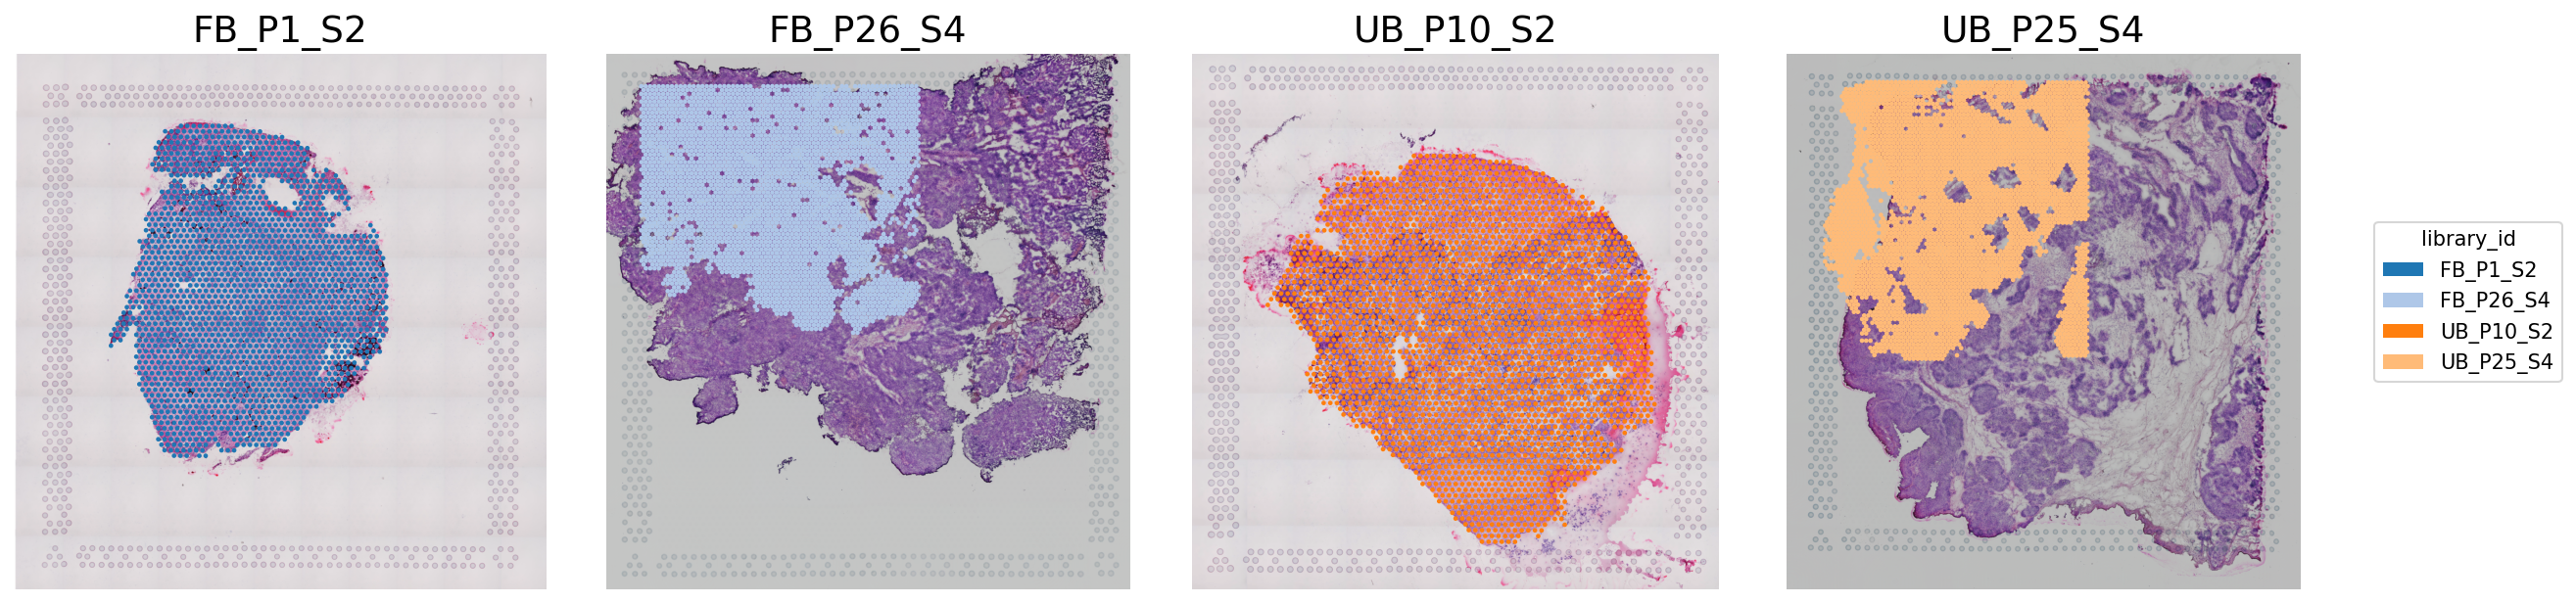

In [13]:
import spatools as st
st.pl.spatial_plot(bdata, 
                   scatter_plot=True, # TODO teste different values here (True, False)
                   sample_key="library_id",
                   group = "library_id")# TODO teste different values here (gene, cluster, response, etc)

In [14]:
### scale factor need fix

namesToFix = [i for i in bdata.uns["spatial"].keys() if i.endswith("S4")]

for name in namesToFix:
    bdata.uns["spatial"][name]["scalefactors"]["tissue_hires_scalef"] = 0.998


In [15]:
namesToFix = [i for i in bdata.uns["spatial"].keys() if i.endswith("S4")]
for i in namesToFix:
    bdata.uns["spatial"][i]["scalefactors"]["tissue_hires_scalef"] = 0.998

In [16]:
bdata.obs

,array_row,array_col,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,library_id
AAACAATCTACTAGCA-1,3,43,2021,7.611842,4906.0,8.498418,37.280881,46.127191,54.912352,68.304117,173.0,5.159055,3.526294,FB_P1_S2
AAACCGGGTAGGTACC-1,42,28,6407,8.765302,20087.0,9.907878,16.055160,23.308608,32.219844,44.909643,435.0,6.077642,2.165580,FB_P1_S2
AAACCGTTCGTCCAGG-1,52,42,3140,8.052296,8603.0,9.059982,37.347437,44.159014,51.958619,63.535976,202.0,5.313206,2.348018,FB_P1_S2
AAACCTCATGAAGTTG-1,37,19,4518,8.416046,12775.0,9.455323,30.896282,38.230920,45.831703,56.743640,1260.0,7.139660,9.863014,FB_P1_S2
AAACGAAGAACATACC-1,6,64,3170,8.061802,12449.0,9.429476,53.843682,59.627279,66.005302,74.520042,182.0,5.209486,1.461965,FB_P1_S2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGTTCAGTGTGCTAC-1-3,24,64,3810,8.245647,9951.0,9.205529,20.259270,29.414129,39.222189,53.944327,148.0,5.003946,1.487288,UB_P25_S4
TTGTTGTGTGTCAAGA-1-3,31,77,3708,8.218518,9806.0,9.190852,20.997349,29.583928,40.026514,55.007138,195.0,5.278115,1.988578,UB_P25_S4
TTGTTTCACATCCAGG-1-2,58,42,2177,7.686162,4773.0,8.470940,23.968154,33.563796,44.688875,60.946994,128.0,4.859812,2.681751,UB_P25_S4
TTGTTTCATTAGTCTA-1-1,60,30,3157,8.057694,8402.0,9.036345,24.815520,35.265413,45.739110,59.569150,133.0,4.897840,1.582957,UB_P25_S4


In [17]:
bdata.obs["response"] = bdata.obs["library_id"].str.split("_").str[0]
bdata.obs["study"] = bdata.obs["library_id"].str.split("_").str[2]

In [18]:
bdata.obs["study"].value_counts()

study
S4    6690
S2    4529
Name: count, dtype: int64

In [19]:
bdata.obs["library_id"].value_counts()

library_id
UB_P25_S4    3472
FB_P26_S4    3218
UB_P10_S2    2679
FB_P1_S2     1850
Name: count, dtype: int64

/mnt/SATA/spatialCourse/.venv/lib/python3.14/site-packages/spatools/plotting/pl.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count_data = adata.obs.groupby([group_by, clusters_col]).size().unstack(fill_value=0)# type: ignore


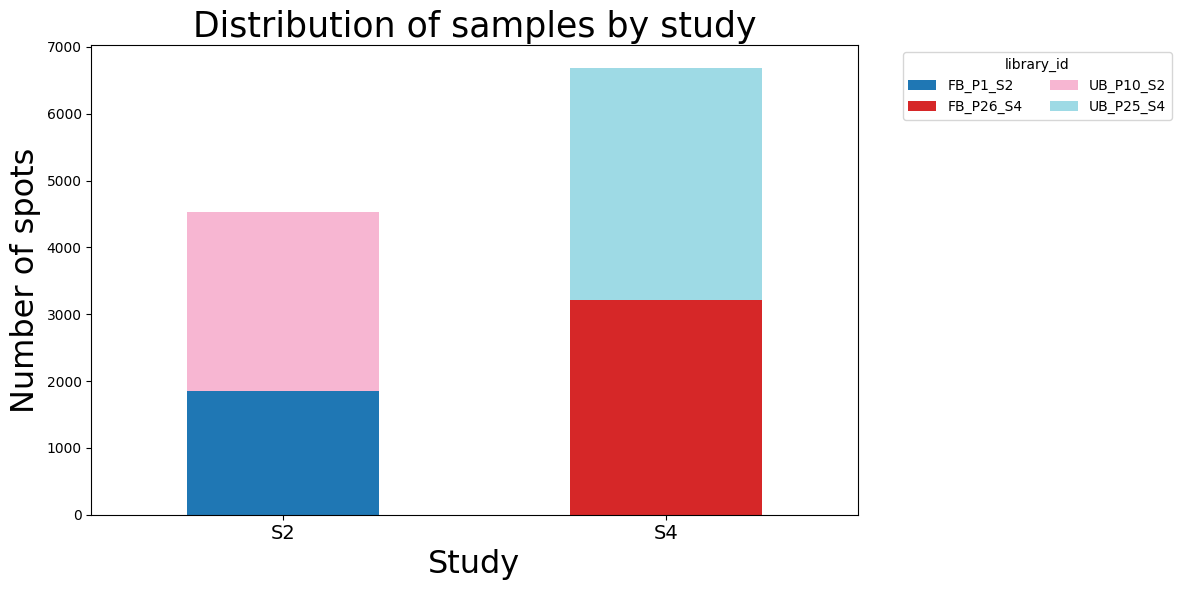

In [20]:
st.pl.bar(
    adata=bdata,
    clusters_col="library_id",
    group_by="study",
    title="Distribution of samples by study",
    xlabel="Study",
    ylabel="Number of spots",
    use_percentage=False, 
    angle=0,
    legend="library_id"
)

In [21]:
bdata.write("/mnt/SATA/spatialCourse/outputIntegrated/spatialPaperFiltered_.h5ad")

# Integration

In [22]:
import scanpy as sc
adata = sc.read("/mnt/SATA/spatialCourse/outputIntegrated/spatialPaperFiltered.h5ad")

In [23]:
adata

AnnData object with n_obs × n_vars = 11219 × 18594
    obs: 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_id'
    uns: 'preprocessing_stats_FB_P1_S2', 'preprocessing_stats_FB_P26_S4', 'preprocessing_stats_UB_P10_S2', 'preprocessing_stats_UB_P25_S4', 'spatial'
    obsm: 'spatial'

In [24]:
adata.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 31946025 stored elements and shape (11219, 18594)>

In [25]:
from copy import deepcopy
adata.layers["counts"] = deepcopy(adata.X)

In [26]:
adata.obs["response"] = bdata.obs["library_id"].str.split("_").str[0]
adata.obs["study"] = bdata.obs["library_id"].str.split("_").str[2]

In [27]:
sc.experimental.pp.normalize_pearson_residuals(adata)

sc.pp.highly_variable_genes(
    adata,
    flavor="seurat_v3",
    n_top_genes=5000, # TODO find best suitable number of genes for you dataset
    batch_key="study",
    layer="counts",
    subset=True
)
sc.pp.scale(adata)

## Autotune

In [28]:
import scvi
scvi.settings.seed = 0

Seed set to 0


In [ ]:
import scvi
import torch
import tempfile
import scanpy as sc
from ray import tune
import seaborn as sns
from scvi import autotune

ImportError: cannot import name 'is_package_installed' from partially initialized module 'scvi.utils' (most likely due to a circular import) (/mnt/SATA/spatialCourse/.venv/lib/python3.14/site-packages/scvi/utils/__init__.py)

In [ ]:
sc.set_figure_params(figsize=(6, 6), frameon=False)
sns.set_theme()
torch.set_float32_matmul_precision("high")
save_dir = tempfile.TemporaryDirectory()
scvi.settings.logging_dir = save_dir.name

%config InlineBackend.print_figure_kwargs={"facecolor": "w"}
%config InlineBackend.figure_format="retina"

In [ ]:
model_cls = scvi.model.SCVI
model_cls.setup_anndata(adata, layer="counts", batch_key="study", categorical_covariate_keys=["library_id"])

In [ ]:
import torch
print(torch.cuda.is_available())  # Should return True if a GPU is detected
print(torch.cuda.device_count())  # Number of GPUs available
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU detected")

True
1
NVIDIA GeForce RTX 3060 Ti


In [2]:
search_space = {
    "n_hidden": tune.choice([64, 128, 256]),
    "n_layers": tune.choice([1, 2, 3]),
}

In [3]:
tuner = autotune.ModelTuner(model_cls)

NameError: name 'autotune' is not defined

In [ ]:
tuner.fit(adata, 
          metric="validation_loss", 
          search_space=search_space, 
          resources = {"cpu": 10, "gpu": 1}
          )

NameError: name 'tuner' is not defined

In [ ]:
model = scvi.model.SCVI(adata, n_hidden=256, n_layers=2)

In [ ]:
model.save(dir_path=fr"/mnt/SATA/spatialCourse/output", overwrite=True)# TODO

In [ ]:
from scvi.model import SCVI

In [ ]:
model.view_anndata_setup(adata)

In [ ]:
model

In [ ]:
sc.write("/mnt/SATA/spatialCourse/output/scvi/scviAnndata.h5ad", adata)

In [ ]:
model.train(use_gpu=True)

In [ ]:
model.save(dir_path=r"/mnt/SATA/spatialCourse/output/scvi_trained", overwrite=True)# TODO

In [ ]:
scvi.__version__

In [ ]:
SCVI_LATENT_KEY = "X_scVI"
adata.obsm[SCVI_LATENT_KEY] = model.get_latent_representation()

In [ ]:
sc.pp.neighbors(adata, use_rep=SCVI_LATENT_KEY)
sc.tl.umap(adata, min_dist=0.2, spread=1)

In [ ]:
sc.tl.leiden(adata, resolution=0.5, key_added="leiden_0.5", flavor="igraph")

In [21]:
BATCH_COLORS = ["#d9b85c",
                "#572f83",
                "#606ed6",
                "#de6259"
                ]
adata.uns["library_id_colors"] = BATCH_COLORS

In [ ]:
my_list = "library_id", "leiden_0.5", "stage", "study", "condition", "response", "chemotype"

for i in my_list:
    sc.pl.umap(adata=adata, color = i, frameon=False)

In [ ]:
adata.write_h5ad(fr"/mnt/SATA/spatialCourse/output.scviAnndataTrained.h5ad")

In [ ]:
adata.obs["leiden_0_6"].value_counts()

In [ ]:
import numpy as np

resolutions = np.arange(0.1, 1.5, 0.1).round(1)

# Run leiden clustering for different resolutions
for resolution in resolutions:
    sc.tl.leiden(
        adata,
        resolution=resolution,
        flavor="igraph",
        key_added=f"leiden_{str(resolution).replace('.', '_')}",
    )

In [ ]:
for resolution in resolutions:
    sc.pl.umap(
        adata,
        color=f"leiden_{str(resolution).replace('.', '_')}",
        frameon=False
    )

In [ ]:
from pyclustree import clustree
import numpy as np

resolutions = np.arange(0.1, 0.8, 0.1).round(1)

fig = clustree(
    adata,
    [f"leiden_{str(resolution).replace('.', '_')}" for resolution in resolutions],
    title="",
    edge_weight_threshold=0.05,  # the minimum fraction of the parent cluster assigned to the child cluster to plot
    show_fraction=True,  # show the fraction of cells in each cluster
    y_spacing=3,  # vertical spacing between clusters
    x_spacing=1.2,  # horizontal spacing between clusters
    show_colorbar=False
)
fig.set_dpi(200)


In [ ]:
sc.tl.leiden(adata=adata, resolution=0.6, key_added="leiden_0.6", flavor="igraph")

## mapping ENS ids to gene_name

In [ ]:
import pandas as pd
import mygene

mg = mygene.MyGeneInfo()

# Transformar o índice do adata.var em lista de strings
ensembl_ids = adata.var.index.tolist()

# Consultar gene symbols
results = mg.querymany(ensembl_ids, scopes='ensembl.gene', fields='symbol', species='human')

# Criar dicionário de mapeamento: se não tiver símbolo, usa o próprio Ensembl ID
id_to_symbol = {r['query']: r.get('symbol', r['query']) for r in results}

# Aplicar o mapeamento
adata.var['gene_symbol'] = adata.var.index.map(id_to_symbol)

# Substituir o índice pelo gene_symbol
adata.var['gene_ids'] = adata.var.index
adata.var.index = adata.var['gene_symbol']
adata.var = adata.var.drop(columns='gene_symbol')

print(adata.var)


In [ ]:
adata.var

In [ ]:
adata.layers["log"] = adata.layers["counts"].copy()

In [ ]:
adata.layers["log"] = adata.layers["log"].copy()
sc.pp.normalize_total(adata, target_sum=1e4, layer="log")
sc.pp.log1p(adata, layer="log")
sc.tl.pca(adata)

In [ ]:
res = "0.6"
resolution = f"leiden_{res}"

sc.tl.rank_genes_groups(adata, groupby=resolution, method="wilcoxon", rankby_abs=False, layer="teste", use_raw=False)
sc.tl.dendrogram(adata, groupby=resolution)
sc.pl.rank_genes_groups_dotplot(adata, groupby=resolution, n_genes=5, values_to_plot="logfoldchanges", dot_min=0.5, cmap='bwr', layer="teste", vmin=-2.5, vmax=2.5)

In [ ]:
st.pl.clusters_quality_violin_boxplot(
    adata,
    clusters_col="leiden_0_9",
    value_col=[
        "pct_counts_mt",
        "log1p_n_genes_by_counts",
        "log1p_total_counts"
    ]
)

In [ ]:
sc.write("/mnt/SATA/spatialCourse/output.scviAnndataTrained_.h5ad", adata)

## Add analitical methods of detecting the  best resolution 